In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [46]:
data = pd.read_excel('Motor Trend Car Road Tests.xlsx')
data.describe()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.0000
mean,20.090625,6.187500,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.8125
std,6.026948,1.785922,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.6152
min,10.400000,4.000000,71.100000,52.000000,2.760000,1.513000,14.500000,0.000000,0.000000,3.000000,1.0000
25%,15.425000,4.000000,120.825000,96.500000,3.080000,2.581250,16.892500,0.000000,0.000000,3.000000,2.0000
50%,19.200000,6.000000,196.300000,123.000000,3.695000,3.325000,17.710000,0.000000,0.000000,4.000000,2.0000
75%,22.800000,8.000000,326.000000,180.000000,3.920000,3.610000,18.900000,1.000000,1.000000,4.000000,4.0000
max,33.900000,8.000000,472.000000,335.000000,4.930000,5.424000,22.900000,1.000000,1.000000,5.000000,8.0000


In [47]:
y = data['mpg']

In [48]:
data = data.drop(columns=['model'])

In [49]:
target_col = 'mpg'
numerical_cols = ['disp', 'hp', 'drat', 'wt', 'qsec']
categorical_cols = ['cyl', 'gear', 'carb']
boolean_cols = ['vs', 'am']

In [50]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [51]:
numerical_transformer = StandardScaler()

categorical_transformer = OneHotEncoder()

In [52]:
pre_processor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols),
        ('bool', 'passthrough', boolean_cols)
    ],
    remainder='drop'
)

In [53]:
model = LinearRegression()

In [54]:
pipeline = Pipeline(
    steps=[
        ('preprocessor', pre_processor),
        ('model', model)
    ]
)

In [55]:
x = data.drop(columns=[target_col])
y = data[target_col]

In [56]:
pipeline.fit(x, y)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [61]:
pipeline.score(x, y)

0.8930749320864843

In [58]:
pipeline["model"].coef_

array([ 4.33618166, -4.75801768,  0.62247393, -4.36239021,  0.64696571,
        0.99495275, -1.65374252,  0.65878977, -1.21425031, -0.09989537,
        1.31414568, -2.4732813 , -3.45263562,  0.52635745, -1.38185841,
        2.00428791,  4.77712996,  1.93085054,  1.2121157 ])

In [62]:
y_predict = pipeline.predict(x)

<function matplotlib.pyplot.show(close=None, block=None)>

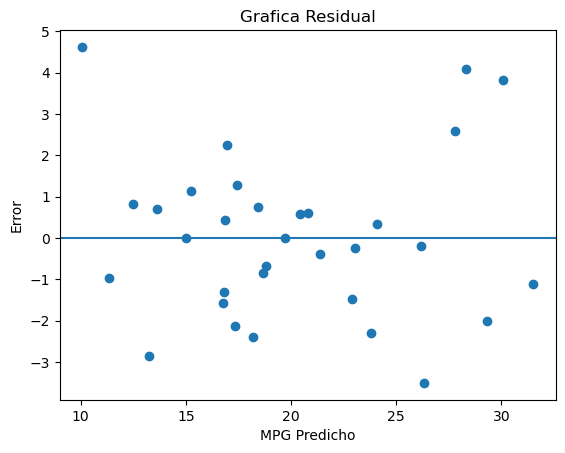

In [63]:
error = y - y_predict

plt.scatter(y_predict,error)

plt.axhline(0)

plt.xlabel("MPG Predicho")
plt.ylabel("Error")
plt.title("Grafica Residual")
plt.show